# scikit-learn Pipelines & Clustering
### Hack-o-Week | ArpitaBuilds

**Covers:**
- scikit-learn workflow: Pipelines (chaining preprocessing + model into one object)
- Clustering: K-Means, Hierarchical (Agglomerative), DBSCAN

**Dataset:** we use scikit-learn's built-in **Breast Cancer Wisconsin** dataset for the pipeline
section (same one as your last notebook, so the comparison is direct), and **synthetic blob/moon
data** for clustering — synthetic data is actually the right choice here because it lets us *see*
clearly what each clustering algorithm is doing on shapes we already know the "correct" answer for.

**Why this matters for your project:**
- Pipelines prevent a sneaky bug called **data leakage** — one of the most common mistakes in ML
  submissions, and something a reviewer will specifically check for
- Clustering is **unsupervised** — no labels needed — so it's a great *exploratory* step before you
  even train your stroke classifier: e.g. "do patients naturally group into risk clusters based on
  age/BMI/glucose, before we even look at who actually had a stroke?"


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_blobs, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 5)
PINK, BLUE, GRAY, ORANGE = '#ff2d78', '#2d9dff', '#888888', '#f5a623'
print("Setup done ✅")

Setup done ✅


---
## 1. The Problem: Doing Preprocessing "By Hand"

In the last notebook we did this:
```python
imputer.fit_transform(X)       # step 1
scaler.fit_transform(X)        # step 2
model.fit(X, y)                # step 3
```
This works, but hides a dangerous trap once you add cross-validation or a train/test split: if you
`fit` the imputer/scaler on the **full dataset** before splitting, information from the test set
(its mean, its median) leaks into training — the model gets an unfair sneak peek. This is called
**data leakage**, and it makes your evaluation metrics look better than they'll actually be in
production.

**Pipelines fix this** by bundling every step into one object, so `fit` and `transform` always happen
in the right order, on the right data, automatically.

In [2]:
# Load data and simulate missing values again, same as last notebook
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

missing_idx = df.sample(frac=0.08, random_state=1).index
df.loc[missing_idx, 'mean radius'] = np.nan

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data ready:", X_train.shape, X_test.shape)

Data ready: (455, 30) (114, 30)


---
## 2. Building a Pipeline

A `Pipeline` is just an ordered list of `(name, step)` pairs. Every step except the last must have
`.fit_transform()` (i.e. be a preprocessor); the last step is your actual model.

In [3]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

# One call does imputation -> scaling -> training, in order
pipeline.fit(X_train, y_train)

test_accuracy = pipeline.score(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.3f}")

Test accuracy: 0.982


**What just happened under the hood:** `pipeline.fit(X_train, y_train)` calls `fit_transform` on
the imputer using **only `X_train`**, then `fit_transform` on the scaler using **only the imputed
`X_train`**, then finally trains the model. When you later call `pipeline.score(X_test, y_test)`, it
calls `.transform()` (not `fit_transform`) on the test data — using statistics learned from *training
only*. Zero leakage, automatically.

In [4]:
# Why this matters even more with cross-validation:
# Each fold gets its OWN imputer/scaler fit on ONLY that fold's training portion.
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
print("CV accuracy per fold:", np.round(cv_scores, 3))
print(f"Mean CV accuracy: {cv_scores.mean():.3f}")

# Compare: doing it "by hand" would accidentally fit the scaler on ALL folds' data before splitting -
# a subtle bug that inflates your reported accuracy without you realizing it.

CV accuracy per fold: [0.967 0.978 0.967 1.    0.989]
Mean CV accuracy: 0.980


**Connects to your project:** once your stroke feature engineering + scaling steps are finalized,
wrap them in a `Pipeline` with your XGBoost model. It becomes one clean, reusable object you can save,
reload, and hand to your Gradio app — no risk of forgetting a preprocessing step at prediction time.

---
## 3. Clustering — Finding Groups Without Labels

Everything so far was **supervised** — we had a `target`/`y` column telling the model the right
answer. Clustering is **unsupervised**: no labels at all. The algorithm just looks at how points are
distributed in feature space and groups similar ones together.

We'll use synthetic 2D data for the first two methods, since it's easy to *see* what "similar" means
before applying it to higher-dimensional real data.

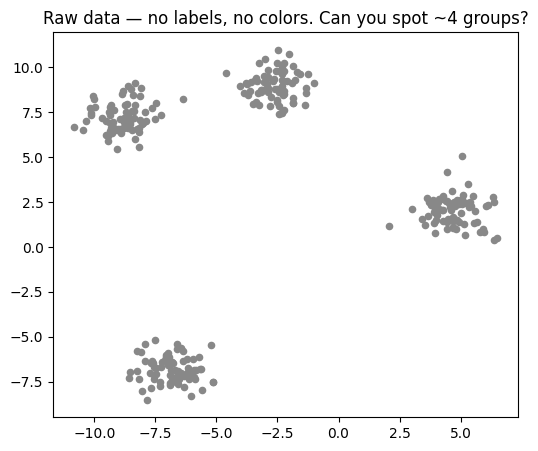

In [5]:
X_blobs, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

plt.scatter(X_blobs[:,0], X_blobs[:,1], color=GRAY, s=20)
plt.title("Raw data — no labels, no colors. Can you spot ~4 groups?")
plt.show()

---
## 4. K-Means

K-Means picks `k` random starting points ("centroids"), then repeats two steps until stable:
1. Assign every point to its **nearest** centroid (distance = the same magnitude/norm idea from your
   linear algebra notebook)
2. Move each centroid to the **average** position of the points assigned to it

You must choose `k` (number of clusters) upfront — the **elbow method** helps pick a good value by
plotting how much error drops as k increases, and looking for where the improvement flattens out.

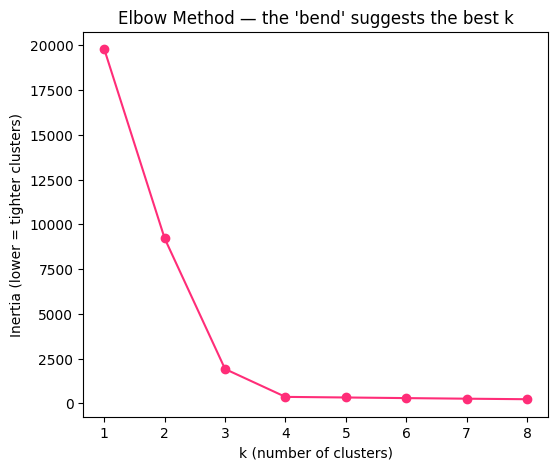

In [6]:
# Elbow method: try k = 1 to 8, track "inertia" (sum of squared distances to nearest centroid)
inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_blobs)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, 'o-', color=PINK)
plt.xlabel('k (number of clusters)'); plt.ylabel('Inertia (lower = tighter clusters)')
plt.title("Elbow Method — the 'bend' suggests the best k")
plt.show()

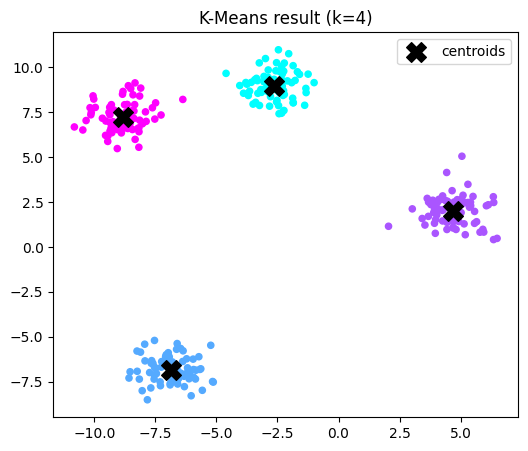

In [7]:
# The elbow points to k=4 -- let's fit and visualize the final clustering
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_blobs)

plt.scatter(X_blobs[:,0], X_blobs[:,1], c=labels, cmap='cool', s=20)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            color='black', marker='X', s=200, label='centroids')
plt.legend(); plt.title("K-Means result (k=4)")
plt.show()

**Key takeaway:** K-Means assumes clusters are roughly round/blob-shaped and similar in size. It's
fast and simple, but you must pick `k`, and it struggles with oddly-shaped clusters (we'll see that
break in the DBSCAN section).

---
## 5. Hierarchical (Agglomerative) Clustering

Instead of picking `k` upfront, this method starts with **every point as its own cluster**, then
repeatedly merges the two closest clusters, one merge at a time, until everything is one big cluster.
The merge history is visualized as a **dendrogram** — a tree you can "cut" at any height to get any
number of clusters, after the fact.

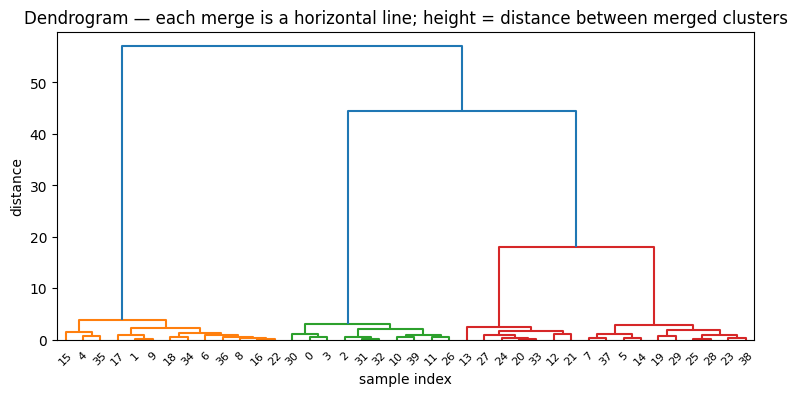

In [8]:
# Use a smaller sample so the dendrogram stays readable
sample_idx = np.random.choice(len(X_blobs), 40, replace=False)
X_sample = X_blobs[sample_idx]

linked = linkage(X_sample, method='ward')   # 'ward' merges to minimize variance growth

plt.figure(figsize=(9, 4))
dendrogram(linked)
plt.title("Dendrogram — each merge is a horizontal line; height = distance between merged clusters")
plt.xlabel("sample index"); plt.ylabel("distance")
plt.show()

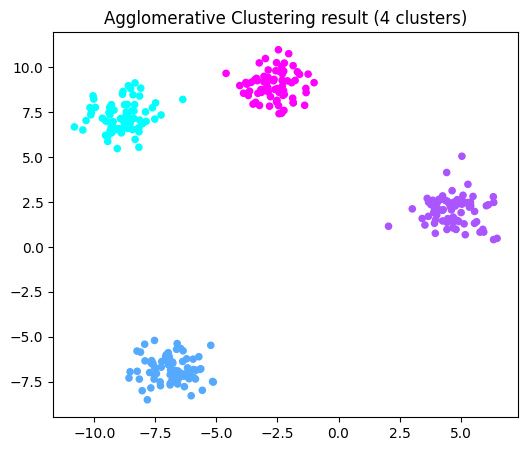

In [9]:
# Cutting the dendrogram at a chosen number of clusters
agglo = AgglomerativeClustering(n_clusters=4)
agglo_labels = agglo.fit_predict(X_blobs)

plt.scatter(X_blobs[:,0], X_blobs[:,1], c=agglo_labels, cmap='cool', s=20)
plt.title("Agglomerative Clustering result (4 clusters)")
plt.show()

**Key takeaway:** the dendrogram is the real value here — you can *look* at it and decide how many
clusters make sense (cut higher = fewer, bigger clusters; cut lower = more, smaller clusters) instead
of guessing `k` blind like K-Means requires.

---
## 6. DBSCAN (Density-Based Clustering)

DBSCAN groups points that are **densely packed together**, and marks isolated points as **noise**
(no cluster at all) instead of forcing every point into a group. It needs no `k` — instead you set:
- `eps`: how close points must be to count as "neighbors"
- `min_samples`: how many neighbors a point needs to be considered a "core" point of a cluster

This lets it find **oddly-shaped clusters** that K-Means completely fails on.

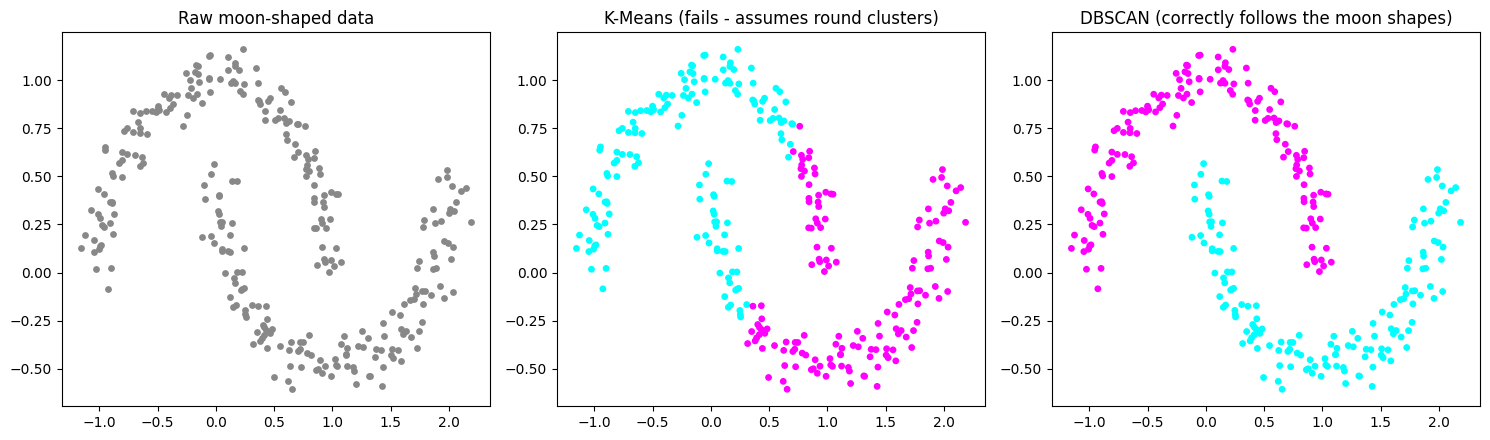

DBSCAN found 2 clusters, and flagged 0 points as noise (label = -1)


In [10]:
# Moon-shaped data - K-Means will fail here because clusters aren't round
X_moons, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(X_moons[:,0], X_moons[:,1], color=GRAY, s=15)
axes[0].set_title("Raw moon-shaped data")

km_labels = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_moons)
axes[1].scatter(X_moons[:,0], X_moons[:,1], c=km_labels, cmap='cool', s=15)
axes[1].set_title("K-Means (fails - assumes round clusters)")

db_labels = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_moons)
axes[2].scatter(X_moons[:,0], X_moons[:,1], c=db_labels, cmap='cool', s=15)
axes[2].set_title("DBSCAN (correctly follows the moon shapes)")

plt.tight_layout()
plt.show()

n_noise = (db_labels == -1).sum()
print(f"DBSCAN found {len(set(db_labels)) - (1 if -1 in db_labels else 0)} clusters, "
      f"and flagged {n_noise} points as noise (label = -1)")

**Key takeaway:** DBSCAN doesn't force a shape assumption, and it naturally identifies outliers as
"noise" rather than cramming them into the nearest cluster — useful for real medical data where a few
patients genuinely don't fit any typical profile (e.g. rare comorbidity combinations).